In [1]:
from llm_metadata_harvester.harvester_operations import metadata_harvest
from llm_metadata_harvester.standards import LTER_LIFE_STANDARD

model_name="surf-openai/gpt-oss-120b"

extracted_metadata = await metadata_harvest(
    model_name=model_name,
    url = "https://datahuiswadden.openearth.nl/geonetwork/srv/api/records/A0h06_NlSEuNlium5OO3FA",
    metadata_standard=LTER_LIFE_STANDARD,
    api_key="77696c6c6d61-fd5bbc82-03d7-45a6-aadf-d783b03afc87"
    )

extracted_metadata

Extracting full page text...


TimeoutError: Page.goto: Timeout 30000ms exceeded.
Call log:
  - navigating to "https://datahuiswadden.openearth.nl/geonetwork/srv/api/records/A0h06_NlSEuNlium5OO3FA", waiting until "networkidle"


In [13]:
from llm_metadata_harvester.webutils import readWebContent, extract_full_page_text

dataPortalURL = [
"https://datahuiswadden.openearth.nl/geonetwork/srv/api/records/A0h06_NlSEuNlium5OO3FA",
"https://datahuiswadden.openearth.nl/geonetwork/srv/eng/catalog.search#/metadata/0fe7e64b-50b3-4cee-b64a-02659fc2b6c7",
"https://datahuiswadden.openearth.nl/geonetwork/srv/eng/catalog.search#/metadata/L-mHomzGRuKAHGMkUPjY9g",
"https://developers.google.com/earth-engine/datasets/catalog/NASA_HLS_HLSS30_v002",
"https://lifesciences.datastations.nl/dataset.xhtml?persistentId=doi:10.17026/dans-2bd-kskz",
"https://lpdaac.usgs.gov/products/mod09a1v061/",
"https://stac.ecodatacube.eu/blue_glad.landsat.ard2.seasconv.m.yearly/collection.json",
"https://stac.ecodatacube.eu/green_glad.landsat.ard2.seasconv.m.yearly/collection.json",
"https://stac.ecodatacube.eu/ndvi_glad.landsat.ard2.seasconv/collection.json?.language=en",
"https://stac.ecodatacube.eu/veg_quercus.robur_anv.eml/collection.json?.language=en",
"https://www.gbif.org/dataset/4fa7b334-ce0d-4e88-aaae-2e0c138d049e",
"https://www.gbif.org/dataset/74196cd9-7ebc-4b20-bc27-3c2d22e31ed7",
"https://www.gbif.org/dataset/bc0acb9a-131f-4085-93ae-a46e08564ac5",
"https://zenodo.org/records/11440456",
"https://zenodo.org/records/8319440"
]

In [14]:
from tqdm import tqdm
from llm_metadata_harvester.harvester_operations import extract_entities
from llm_metadata_harvester.llm_client import LLMClient
import nest_asyncio
initial_url_map = {}
clean_url_map = {}

index = 0


for url in dataPortalURL:
    print(index)
    index += 1
    # Apply nest_asyncio to allow asyncio.run() in Jupyter
    nest_asyncio.apply()

    # Run the async function
    if url.startswith("https://lpdaac.usgs.gov") \
        or url.startswith("https://datahuiswadden.openearth.nl") \
        or url.startswith("https://www.gbif.org"):
        soup = readWebContent(url)
        if soup is None:
            continue
            raise ValueError("Failed to retrieve web content", url)

        # Extract text from the webpage - adjust the selector based on the webpage structure
        # This is a basic example - you might need to modify based on the specific webpage
        full_text = soup.get_text(separator='\n', strip=True)
    else:
        full_text = await extract_full_page_text(url, timeout=800000)
    
    llm = LLMClient(model_name=model_name,
                    temperature=0.0,
                    api_key="77696c6c6d61-4a075398-8a11-4b24-bd5b-8054469c3860"
                    )

    clean_nodes = extract_entities(
        text=full_text,
        meta_field_dict=LTER_LIFE_STANDARD,
        llm=llm
    )

    # Create a dictionary to store entity_type: [(entity_name, description), ...]
    clean_entity_type_map = {}

    for entity_group in clean_nodes.values():
        for item in entity_group:
            entity_name = item.get('entity_name')
            entity_value = item.get('entity_value')

            # Initialize the list for this entity_type if not already present
            if entity_name not in clean_entity_type_map:
                clean_entity_type_map[entity_name] = []

            # Append the (entity_name, description) pair
            clean_entity_type_map[entity_name].append(entity_value)
    clean_url_map[url] = clean_entity_type_map

0
1
2
3
4
5
Failed to retrieve the webpage.
6
7
8
9
10
Failed to retrieve the webpage.
11
Failed to retrieve the webpage.
12
Failed to retrieve the webpage.
13
14


In [15]:
clean_url_map

{'https://datahuiswadden.openearth.nl/geonetwork/srv/api/records/A0h06_NlSEuNlium5OO3FA': {'Metadata date': ['2016-11-01'],
  'Metadata language': ['Nederlands; Vlaams'],
  'Responsible organization metadata': ['Wageningen Marine Research'],
  'Landing page': ['Wadden viewer (online resource)']},
 'https://datahuiswadden.openearth.nl/geonetwork/srv/eng/catalog.search#/metadata/0fe7e64b-50b3-4cee-b64a-02659fc2b6c7': {'Metadata date': ['N/A'],
  'Metadata language': ['N/A'],
  'Responsible organization metadata': ['N/A'],
  'Landing page': ['N/A'],
  'Title': ['Waddenregister'],
  'Description': ['Waddenregister is a geospatial dataset covering the Wadden Sea region.'],
  'Unique Identifier': ['N/A'],
  'Resource type': ['geospatial dataset'],
  'Keywords': ['Wadden Sea'],
  'Data creator': ['N/A'],
  'Data contact point': ['N/A'],
  'Data publisher': ['N/A'],
  'Spatial coverage': ['Wadden Sea region'],
  'Spatial resolution': ['N/A'],
  'Spatial reference system': ['N/A'],
  'Temporal 

In [16]:
import yaml
import os

from datetime import datetime
now = datetime.now()
date_str = now.strftime("%Y-%m-%d")
prefix = "lterlife_"+model_name.replace("/", "_")+"_"

output_file_path = "outputs/" + date_str + "/" + prefix + "clean_entity_type_map.yaml"
os.makedirs(os.path.dirname(output_file_path), exist_ok=True)

# Sort the inner dictionary keys for each dataset URL
sorted_data = {
    url: dict(sorted(fields.items()))
    for url, fields in clean_url_map.items()
}

# Save to YAML
with open(output_file_path, "w") as file:
    yaml.dump(sorted_data, file, sort_keys=False, allow_unicode=True)

In [5]:
pip install rouge_score

  Preparing metadata (setup.py) ... done
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24986 sha256=76bd442522b962c3b5020c53a6336a69e29b925c66ad277f416bb07625ee81df
  Stored in directory: /home/com3dian/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge_score
Note: you may need to restart the kernel to use updated packages.


In [1]:
# ==============================================================================
# Evaluation Section: Compare 2026-02-27 predictions with ground truth
# ==============================================================================

%load_ext autoreload
%autoreload 2

import yaml
import os
import datetime
from tqdm import tqdm
import pandas as pd
from dotenv import load_dotenv
load_dotenv(dotenv_path='keys.env')

from ragas import SingleTurnSample 
from ragas.metrics import RougeScore
from ragas.metrics._string import NonLLMStringSimilarity, DistanceMeasure
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
sns.set_palette('colorblind')

fig_dir = 'figs/'
def despine(ax):
    for sp in ['top', 'right']:
        ax.spines[sp].set_visible(False)
    return ax

/home/com3dian/miniconda3/envs/sam2/lib/python3.12/site-packages/instructor/providers/gemini/client.py:5: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai  # type: ignore[import-not-found]
/tmp/ipykernel_11510/3133438881.py:17: DeprecationWarning: Importing RougeScore from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import RougeScore
  from ragas.metrics import RougeScore


In [2]:
# Helper functions for loading and processing predictions and annotations

def load_yaml(file_path):
    with open(file_path, 'r') as file:
        return yaml.safe_load(file)

class Labels:
    """Class to handle metadata labels (both predictions and annotations)."""
    def __init__(self, labels, list_ds_urls, list_metadata_fields, has_findability=False):
        self.labels = labels
        self.list_ds_urls = list_ds_urls
        self.list_metadata_fields = list_metadata_fields
        self.findability_exists = has_findability
        self.context_lists = {url: [] for url in self.list_ds_urls}
        
    def get_text(self, url, field):
        if url not in self.labels:
            return None
        if field not in self.labels[url]:
            return None
        
        md_val = self.labels[url][field]
        if self.findability_exists and isinstance(md_val, dict):
            field_val = md_val.get('text', None)
        elif isinstance(md_val, list):
            field_val = md_val[0] if md_val else None
        else:
            field_val = md_val
            
        if isinstance(field_val, datetime.date):
            field_val = field_val.strftime('%Y-%m-%d')
        return str(field_val) if field_val is not None else None
    
    def get_findability(self, url, field):
        if not self.findability_exists:
            return None
        if url not in self.labels or field not in self.labels[url]:
            return None
        md_val = self.labels[url][field]
        if isinstance(md_val, dict):
            return md_val.get('findability', None)
        return None
    
    def keys(self):
        return self.labels.keys()
    
    def __len__(self):
        return len(self.labels)

def load_pred_and_annot_lterlife(fp_pred, fp_annot, keep_annotated_fields_only=True):
    """Load predictions and annotations for LTER-LIFE format comparison."""
    labels_annot_raw = load_yaml(fp_annot)
    labels_pred_raw = load_yaml(fp_pred)
    
    # Find common URLs between predictions and annotations
    common_urls = set(labels_annot_raw.keys()) & set(labels_pred_raw.keys())
    print(f"Found {len(common_urls)} common URLs between predictions and annotations")
    print(f"Predictions only: {set(labels_pred_raw.keys()) - set(labels_annot_raw.keys())}")
    print(f"Annotations only: {set(labels_annot_raw.keys()) - set(labels_pred_raw.keys())}")
    
    list_ds_urls = list(common_urls)
    
    # Get metadata fields from annotations (use LTER-LIFE standard fields)
    metadata_fields_annot = set()
    for url in list_ds_urls:
        metadata_fields_annot.update(labels_annot_raw[url].keys())
    metadata_fields_annot = sorted(list(metadata_fields_annot))
    
    # Filter predictions to only include annotated fields if requested
    if keep_annotated_fields_only:
        for url in labels_pred_raw:
            for key in list(labels_pred_raw[url].keys()):
                if key not in metadata_fields_annot:
                    del labels_pred_raw[url][key]
    
    labels_annot = Labels(labels_annot_raw, list_ds_urls, metadata_fields_annot, has_findability=True)
    labels_pred = Labels(labels_pred_raw, list_ds_urls, metadata_fields_annot, has_findability=False)
    
    print(f"Loaded {len(list_ds_urls)} datasets with {len(metadata_fields_annot)} metadata fields")
    return labels_annot, labels_pred, (list_ds_urls, metadata_fields_annot)

In [3]:
# Configuration for evaluation
# Include SURF models (2026-02-27) and Gemini/OpenAI results from multiple dates
folder_pred_surf = 'outputs/2026-02-27/'
folder_pred_gemini_openai_old = 'outputs/2025-06-06/'  # Has matching URLs with ground truth
folder_pred_openai_new = 'outputs/2025-07-01/'  # Latest OpenAI results
folder_pred_gemini_new = 'outputs/2025-07-22/'  # Latest Gemini results

# Use the same ground truth as in Evaluate LLM output.ipynb, with fallback
fp_annot_primary = 'outputs/annotations/ground_truth_metadata_annotations-2025-06-04.yaml'
fp_annot_fallback = 'outputs/annotations/ground_truth_metadata_annotations-2025-05-30.yaml'

if os.path.exists(fp_annot_primary):
    fp_annot = fp_annot_primary
    print(f"Using primary ground truth file: {fp_annot}")
elif os.path.exists(fp_annot_fallback):
    fp_annot = fp_annot_fallback
    print(f"Primary file not found, using fallback ground truth file: {fp_annot}")
else:
    raise FileNotFoundError(f"Neither {fp_annot_primary} nor {fp_annot_fallback} found!")

# Model name mapping for display
model_name_mapping = {
    # SURF models (2026-02-27)
    'surf-default-text-large': 'SURF Default Text Large',
    'surf-mistralai_Mistral-Small-3.2-24B-Instruct-2506': 'Mistral Small 3.2 24B',
    'surf-openai_gpt-oss-120b': 'GPT-OSS 120B',
    'surf-Qwen 2.5 Coder 32B Instruct AWQ': 'Qwen 2.5 Coder 32B',
    'surf-Qwen 2.5 VL 32B Instruct AWQ': 'Qwen 2.5 VL 32B',
    # Gemini and OpenAI models - multiple versions
    'gemini_2025-06-06': 'Gemini (2025-06-06)',
    'openai_2025-06-06': 'GPT-4 (2025-06-06)',
    'gemini_2025-07-22': 'Gemini (2025-07-22)',
    'openai_2025-07-01': 'GPT-4 (2025-07-01)',
}

# URL to dataset name mapping for visualization
url_to_ds_name = {
    'https://lifesciences.datastations.nl/dataset.xhtml?persistentId=doi:10.17026/dans-2bd-kskz': 'Dutch forest reserves database and network (DANS)',
    'https://www.gbif.org/dataset/4fa7b334-ce0d-4e88-aaae-2e0c138d049e': 'eBird observation dataset (GBIF)',
    'https://www.gbif.org/dataset/74196cd9-7ebc-4b20-bc27-3c2d22e31ed7': 'Waterleidingduinen camera trap P1 (GBIF)',
    'https://www.gbif.org/dataset/f9ba3c2e-0636-4f66-a4b5-b8c138046e9e': 'Waterleidingduinen camera trap P2 (GBIF)',
    'https://www.gbif.org/dataset/bc0acb9a-131f-4085-93ae-a46e08564ac5': 'Waterleidingduinen camera trap P3 (GBIF)',
    'https://zenodo.org/records/11440456': 'Waterleidingduinen camera trap P1-3 (Zenodo)',
    'https://stac.ecodatacube.eu/blue_glad.landsat.ard2.seasconv.m.yearly/collection.json': 'Cloud-free reconstructed Landsat yearly blue band (EcoDataCube)',
    'https://stac.ecodatacube.eu/green_glad.landsat.ard2.seasconv.m.yearly/collection.json': 'Cloud-free reconstructed Landsat yearly green band (EcoDataCube)',
    'https://datahuiswadden.openearth.nl/geonetwork/srv/api/records/A0h06_NlSEuNlium5OO3FA': 'Ecotopenkaart 2016 (Datahuis Wadden)',
    'https://datahuiswadden.openearth.nl/geonetwork/srv/eng/catalog.search#/metadata/L-mHomzGRuKAHGMkUPjY9g': 'Ecotopenkaart 2017 (Datahuis Wadden)',
    'https://developers.google.com/earth-engine/datasets/catalog/NASA_HLS_HLSS30_v002': 'Harmonized Landsat Sentinel-2 (Google Earth Engine)',
    'https://lpdaac.usgs.gov/products/mod09a1v061/': 'MODIS Terra MOD09A1 Version 6.1 (LP DAAC)',
    'https://stac.ecodatacube.eu/ndvi_glad.landsat.ard2.seasconv/collection.json?.language=en': 'Cloud-free reconstructed Landsat bimonthly NDVI (EcoDataCube)',
    'https://stac.ecodatacube.eu/veg_quercus.robur_anv.eml/collection.json?.language=en': 'Actual probability distribution for Quercus robur (EcoDataCube)',
    'https://zenodo.org/records/8319440': 'Downscaled LUH2 land use scenarios for Belgium (Zenodo)',
    'https://datahuiswadden.openearth.nl/geonetwork/srv/eng/catalog.search#/metadata/0fe7e64b-50b3-4cee-b64a-02659fc2b6c7': 'Waddenbalans 2024 (Datahuis Wadden)',
}

domain_to_provider = {
    'datahuiswadden.openearth.nl': 'Datahuis Wadden', 
    'developers.google.com': 'Google Earth Engine',
    'lifesciences.datastations.nl': 'DANS Datastations', 
    'lpdaac.usgs.gov': 'LP DAAC',
    'stac.ecodatacube.eu': 'EcoDataCube', 
    'gbif.org': 'GBIF', 
    'zenodo.org': 'Zenodo'
}

# Collect all prediction files from all folders
# Structure: list of (folder_path, filename, model_source, date_suffix) tuples
fp_pred_list = []

# SURF models from 2026-02-27
if os.path.exists(folder_pred_surf):
    for f in os.listdir(folder_pred_surf):
        if f.endswith('.yaml'):
            fp_pred_list.append((folder_pred_surf, f, 'lterlife', ''))
    print(f"Found {len([x for x in fp_pred_list if x[2] == 'lterlife'])} prediction files in {folder_pred_surf}")

# Gemini and OpenAI models from 2025-06-06 (cedar format, clean only)
if os.path.exists(folder_pred_gemini_openai_old):
    for f in os.listdir(folder_pred_gemini_openai_old):
        if f.endswith('.yaml') and 'cedar' in f and 'clean' in f:
            fp_pred_list.append((folder_pred_gemini_openai_old, f, 'cedar', '2025-06-06'))
    print(f"Found {len([x for x in fp_pred_list if x[3] == '2025-06-06'])} prediction files in {folder_pred_gemini_openai_old}")

# Latest OpenAI from 2025-07-01 (cedar format, clean only)
if os.path.exists(folder_pred_openai_new):
    for f in os.listdir(folder_pred_openai_new):
        if f.endswith('.yaml') and 'cedar' in f and 'clean' in f and 'openai' in f:
            fp_pred_list.append((folder_pred_openai_new, f, 'cedar', '2025-07-01'))
    print(f"Found {len([x for x in fp_pred_list if x[3] == '2025-07-01'])} OpenAI prediction files in {folder_pred_openai_new}")

# Latest Gemini from 2025-07-22 (cedar format, clean only)
if os.path.exists(folder_pred_gemini_new):
    for f in os.listdir(folder_pred_gemini_new):
        if f.endswith('.yaml') and 'cedar' in f and 'clean' in f and 'gemini' in f:
            fp_pred_list.append((folder_pred_gemini_new, f, 'cedar', '2025-07-22'))
    print(f"Found {len([x for x in fp_pred_list if x[3] == '2025-07-22'])} Gemini prediction files in {folder_pred_gemini_new}")

print(f"\nTotal: {len(fp_pred_list)} prediction files to evaluate:")
for folder, fp, source, date_suffix in fp_pred_list:
    print(f"  - [{source}] {folder}{fp}")

Using primary ground truth file: outputs/annotations/ground_truth_metadata_annotations-2025-06-04.yaml
Found 5 prediction files in outputs/2026-02-27/
Found 2 prediction files in outputs/2025-06-06/
Found 1 OpenAI prediction files in outputs/2025-07-01/
Found 1 Gemini prediction files in outputs/2025-07-22/

Total: 9 prediction files to evaluate:
  - [lterlife] outputs/2026-02-27/lterlife_surf-Qwen 2.5 Coder 32B Instruct AWQ_clean_entity_type_map.yaml
  - [lterlife] outputs/2026-02-27/lterlife_surf-openai_gpt-oss-120b_clean_entity_type_map.yaml
  - [lterlife] outputs/2026-02-27/lterlife_surf-Qwen 2.5 VL 32B Instruct AWQ_clean_entity_type_map.yaml
  - [lterlife] outputs/2026-02-27/lterlife_surf-mistralai_Mistral-Small-3.2-24B-Instruct-2506_clean_entity_type_map.yaml
  - [lterlife] outputs/2026-02-27/lterlife_surf-default-text-large_clean_entity_type_map.yaml
  - [cedar] outputs/2025-06-06/cedar_gemini_clean_entity_type_map.yaml
  - [cedar] outputs/2025-06-06/cedar_openai_clean_entity_ty

In [4]:
# Main evaluation loop - evaluate all prediction files
cols_evaluation = ['model_name', 'model_source', 'url', 'metadata_field', 'findability',  
                   'annot_missing', 'value_annot', 'value_pred',
                   'rouge', 'levenshtein']
ds_scores = {x: [] for x in cols_evaluation}
count_it = 0

for folder_path, fp_pred, model_source, date_suffix in fp_pred_list:
    if not fp_pred.endswith('.yaml'):
        continue
    
    # Extract model name from filename based on source format
    if model_source == 'lterlife':
        # Format: lterlife_<model_name>_clean_entity_type_map.yaml
        model_name_raw = fp_pred.replace('lterlife_', '').replace('_clean_entity_type_map.yaml', '')
    elif model_source == 'cedar':
        # Format: cedar_<model_name>_clean_entity_type_map.yaml
        model_name_raw = fp_pred.replace('cedar_', '').replace('_clean_entity_type_map.yaml', '')
        # Add date suffix for cedar models to distinguish versions
        if date_suffix:
            model_name_raw = f"{model_name_raw}_{date_suffix}"
    else:
        model_name_raw = fp_pred
    
    model_name_display = model_name_mapping.get(model_name_raw, model_name_raw)
    
    print(f"\n{'='*60}")
    print(f"Evaluating predictions from {folder_path}{fp_pred}")
    print(f"Model: {model_name_display} (source: {model_source})")
    print(f"{'='*60}")
    
    try:
        labels_annot, labels_pred, (list_ds_urls, list_metadata_fields) = load_pred_and_annot_lterlife(
            fp_pred=os.path.join(folder_path, fp_pred), 
            fp_annot=fp_annot, 
            keep_annotated_fields_only=True
        )
    except Exception as e:
        print(f"Error loading {fp_pred}: {e}")
        continue
    
    # Warn if no common URLs found between predictions and ground truth
    if len(list_ds_urls) == 0:
        print(f"⚠️  WARNING: No common URLs found for {model_name_display} - skipping (URL mismatch with ground truth)")
        continue
    
    print(f"Found {len(list_ds_urls)} common URLs with ground truth")

    excluded_fields = {'Description', 'Keywords'}
    list_metadata_fields_eval = [x for x in list_metadata_fields if x not in excluded_fields]
    if len(list_metadata_fields_eval) != len(list_metadata_fields):
        print(f"Excluding fields from evaluation: {sorted(excluded_fields)}")

    for col_evaluate in tqdm(list_metadata_fields_eval, desc=f"Evaluating {model_name_display}"):
        for url in list_ds_urls:
            count_it += 1
            ds_scores['url'].append(url)
            ds_scores['metadata_field'].append(col_evaluate)
            ds_scores['findability'].append(labels_annot.get_findability(url, col_evaluate))
            ds_scores['model_name'].append(model_name_display)
            ds_scores['model_source'].append(model_source)

            field_annot = labels_annot.get_text(url, col_evaluate)
            field_pred = labels_pred.get_text(url, col_evaluate)
            
            # Handle missing values
            if field_annot is None:
                field_annot = 'N/A'
            if field_pred is None:
                field_pred = 'N/A'
            
            ds_scores['value_annot'].append(field_annot)
            ds_scores['value_pred'].append(field_pred)

            test_data = SingleTurnSample(
                user_input=f'What is the {col_evaluate} of this dataset?',
                response=field_pred,
                reference=field_annot,
                retrieved_contexts=[]
            )

            # Check if annotation is marked as unavailable
            if field_annot == 'N/A':
                ds_scores['annot_missing'].append(True)
                missing_indicators = ['n/a', 'none', '', 'not specified', 'not available', 
                                      'not applicable', 'not provided', 'not given']
                if field_pred is None or field_pred.lower() in missing_indicators:
                    ds_scores['rouge'].append(1.0)
                    ds_scores['levenshtein'].append(1.0)
                    continue
            else:
                ds_scores['annot_missing'].append(False)

            # Calculate Levenshtein similarity
            levenshtein_scorer = NonLLMStringSimilarity(distance_measure=DistanceMeasure.LEVENSHTEIN)
            levenshtein_sim = levenshtein_scorer.single_turn_score(test_data)
            ds_scores['levenshtein'].append(levenshtein_sim)

            # Calculate ROUGE-L score
            rouge_scorer = RougeScore(rouge_type='rougeL', mode='fmeasure')
            rouge_score = rouge_scorer.single_turn_score(test_data)
            ds_scores['rouge'].append(rouge_score)

print(f"\n{'='*60}")
print(f"Evaluation complete! Total evaluations: {count_it}")
print(f"{'='*60}")


Evaluating predictions from outputs/2026-02-27/lterlife_surf-Qwen 2.5 Coder 32B Instruct AWQ_clean_entity_type_map.yaml
Model: Qwen 2.5 Coder 32B (source: lterlife)
Found 11 common URLs between predictions and annotations
Predictions only: set()
Annotations only: {'https://www.gbif.org/dataset/4fa7b334-ce0d-4e88-aaae-2e0c138d049e', 'https://lpdaac.usgs.gov/products/mod09a1v061/', 'https://www.gbif.org/dataset/f9ba3c2e-0636-4f66-a4b5-b8c138046e9e', 'https://www.gbif.org/dataset/74196cd9-7ebc-4b20-bc27-3c2d22e31ed7', 'https://www.gbif.org/dataset/bc0acb9a-131f-4085-93ae-a46e08564ac5'}
Loaded 11 datasets with 24 metadata fields
Found 11 common URLs with ground truth
Excluding fields from evaluation: ['Description', 'Keywords']


Evaluating Qwen 2.5 Coder 32B: 100%|██████████| 22/22 [00:01<00:00, 15.90it/s]



Evaluating predictions from outputs/2026-02-27/lterlife_surf-openai_gpt-oss-120b_clean_entity_type_map.yaml
Model: GPT-OSS 120B (source: lterlife)
Found 11 common URLs between predictions and annotations
Predictions only: set()
Annotations only: {'https://www.gbif.org/dataset/4fa7b334-ce0d-4e88-aaae-2e0c138d049e', 'https://lpdaac.usgs.gov/products/mod09a1v061/', 'https://www.gbif.org/dataset/f9ba3c2e-0636-4f66-a4b5-b8c138046e9e', 'https://www.gbif.org/dataset/74196cd9-7ebc-4b20-bc27-3c2d22e31ed7', 'https://www.gbif.org/dataset/bc0acb9a-131f-4085-93ae-a46e08564ac5'}
Loaded 11 datasets with 24 metadata fields
Found 11 common URLs with ground truth
Excluding fields from evaluation: ['Description', 'Keywords']


Evaluating GPT-OSS 120B: 100%|██████████| 22/22 [00:00<00:00, 824.90it/s]



Evaluating predictions from outputs/2026-02-27/lterlife_surf-Qwen 2.5 VL 32B Instruct AWQ_clean_entity_type_map.yaml
Model: Qwen 2.5 VL 32B (source: lterlife)
Found 11 common URLs between predictions and annotations
Predictions only: set()
Annotations only: {'https://www.gbif.org/dataset/4fa7b334-ce0d-4e88-aaae-2e0c138d049e', 'https://lpdaac.usgs.gov/products/mod09a1v061/', 'https://www.gbif.org/dataset/f9ba3c2e-0636-4f66-a4b5-b8c138046e9e', 'https://www.gbif.org/dataset/74196cd9-7ebc-4b20-bc27-3c2d22e31ed7', 'https://www.gbif.org/dataset/bc0acb9a-131f-4085-93ae-a46e08564ac5'}
Loaded 11 datasets with 24 metadata fields
Found 11 common URLs with ground truth
Excluding fields from evaluation: ['Description', 'Keywords']


...

Evaluating Gemini (2025-06-06): 100%|██████████| 22/22 [00:00<00:00, 434.40it/s]



Evaluating predictions from outputs/2025-06-06/cedar_openai_clean_entity_type_map.yaml
Model: GPT-4 (2025-06-06) (source: cedar)
Found 16 common URLs between predictions and annotations
Predictions only: set()
Annotations only: set()
Loaded 16 datasets with 24 metadata fields
Found 16 common URLs with ground truth
Excluding fields from evaluation: ['Description', 'Keywords']


Evaluating GPT-4 (2025-06-06): 100%|██████████| 22/22 [00:00<00:00, 451.21it/s]


Evaluating predictions from outputs/2025-07-01/cedar_openai_clean_entity_type_map.yaml
Model: GPT-4 (2025-07-01) (source: cedar)


Found 0 common URLs between predictions and annotations
Predictions only: {'https://data.4tu.nl/articles/dataset/Data_underlying_the_paper_Planktonic_primary_production_in_the_western_Dutch_Wadden_Sea/12872684/1'}
Annotations only: {'https://www.gbif.org/dataset/4fa7b334-ce0d-4e88-aaae-2e0c138d049e', 'https://stac.ecodatacube.eu/ndvi_glad.landsat.ard2.seasconv/collection.json?.language=en', 'https://datahuiswadden.openearth.nl/geonetwork/srv/api/records/A0h06_NlSEuNlium5OO3FA', 'https://stac.ecodatacube.eu/blue_glad.landsat.ard2.seasconv.m.yearly/collection.json', 'https://zenodo.org/records/11440456', 'https://zenodo.org/records/8319440', 'https://www.gbif.org/dataset/74196cd9-7ebc-4b20-bc27-3c2d22e31ed7', 'https://stac.ecodatacube.eu/veg_quercus.robur_anv.eml/collection.json?.language=en', 'https://lifesciences.datastations.nl/dataset.xhtml?persistentId=doi:10.17026/dans-2bd-kskz', 'https://datahuiswadden.openearth.nl/geonetwork/srv/eng/catalog.search#/metadata/L-mHomzGRuKAHGMkUPjY9g

In [5]:
# Convert results to DataFrame and add derived columns
ds_scores_clean = {k: v for k, v in ds_scores.items() if len(v) == count_it}
print(f'Dropped {len(ds_scores) - len(ds_scores_clean)} columns with missing values.')

df_scores = pd.DataFrame(ds_scores_clean)
df_scores['domain'] = df_scores['url'].apply(lambda x: x.lstrip('https://').lstrip('www.').split('/')[0])
df_scores['provider'] = df_scores['domain'].apply(lambda x: domain_to_provider.get(x, x))
df_scores['name'] = df_scores['url'].apply(lambda x: url_to_ds_name.get(x, x))

# Create filtered dataframes based on findability
df_scores_present_structured = df_scores[df_scores['findability'] == 1].copy()
df_scores_present_unstructured = df_scores[df_scores['findability'] == 2].copy()
df_scores_missing = df_scores[df_scores['annot_missing'] == True].copy()

# Summary statistics
print(f"\n{'='*60}")
print("Summary Statistics")
print(f"{'='*60}")
print(f"Total evaluations: {len(df_scores)}")
print(f"  - Structured metadata (findability=1): {len(df_scores_present_structured)}")
print(f"  - Unstructured metadata (findability=2): {len(df_scores_present_unstructured)}")
print(f"  - Missing annotations: {len(df_scores_missing)}")
print(f"\nModels evaluated: {df_scores['model_name'].unique().tolist()}")
print(f"Metadata fields: {df_scores['metadata_field'].nunique()}")
print(f"Datasets: {df_scores['url'].nunique()}")

# Display first few rows
df_scores.head(10)

Dropped 0 columns with missing values.

Summary Statistics
Total evaluations: 1914
  - Structured metadata (findability=1): 675
  - Unstructured metadata (findability=2): 663
  - Missing annotations: 576

Models evaluated: ['Qwen 2.5 Coder 32B', 'GPT-OSS 120B', 'Qwen 2.5 VL 32B', 'Mistral Small 3.2 24B', 'SURF Default Text Large', 'Gemini (2025-06-06)', 'GPT-4 (2025-06-06)']
Metadata fields: 22
Datasets: 16


,model_name,model_source,url,metadata_field,findability,annot_missing,value_annot,value_pred,rouge,levenshtein,domain,provider,name
0,Qwen 2.5 Coder 32B,lterlife,https://stac.ecodatacube.eu/ndvi_glad.landsat....,Access rights,0,True,N/A,N/A,1.0,1.000000,ac.ecodatacube.eu,ac.ecodatacube.eu,Cloud-free reconstructed Landsat bimonthly NDV...
1,Qwen 2.5 Coder 32B,lterlife,https://datahuiswadden.openearth.nl/geonetwork...,Access rights,1,False,"Copyright, no user limitations",N/A,0.0,0.000000,datahuiswadden.openearth.nl,Datahuis Wadden,Ecotopenkaart 2016 (Datahuis Wadden)
2,Qwen 2.5 Coder 32B,lterlife,https://developers.google.com/earth-engine/dat...,Access rights,1,False,NASA promotes the full and open sharing of all...,N/A,0.0,0.013605,developers.google.com,Google Earth Engine,Harmonized Landsat Sentinel-2 (Google Earth En...
3,Qwen 2.5 Coder 32B,lterlife,https://stac.ecodatacube.eu/blue_glad.landsat....,Access rights,0,True,N/A,N/A,1.0,1.000000,ac.ecodatacube.eu,ac.ecodatacube.eu,Cloud-free reconstructed Landsat yearly blue b...
4,Qwen 2.5 Coder 32B,lterlife,https://zenodo.org/records/11440456,Access rights,2,False,The data are freely available,N/A,0.0,0.000000,zenodo.org,Zenodo,Waterleidingduinen camera trap P1-3 (Zenodo)
5,Qwen 2.5 Coder 32B,lterlife,https://zenodo.org/records/8319440,Access rights,0,True,N/A,N/A,1.0,1.000000,zenodo.org,Zenodo,Downscaled LUH2 land use scenarios for Belgium...
6,Qwen 2.5 Coder 32B,lterlife,https://stac.ecodatacube.eu/green_glad.landsat...,Access rights,0,True,N/A,N/A,1.0,1.000000,ac.ecodatacube.eu,ac.ecodatacube.eu,Cloud-free reconstructed Landsat yearly green ...
7,Qwen 2.5 Coder 32B,lterlife,https://stac.ecodatacube.eu/veg_quercus.robur_...,Access rights,0,True,N/A,N/A,1.0,1.000000,ac.ecodatacube.eu,ac.ecodatacube.eu,Actual probability distribution for Quercus ro...
8,Qwen 2.5 Coder 32B,lterlife,https://lifesciences.datastations.nl/dataset.x...,Access rights,0,True,N/A,N/A,1.0,1.000000,lifesciences.datastations.nl,DANS Datastations,Dutch forest reserves database and network (DANS)
9,Qwen 2.5 Coder 32B,lterlife,https://datahuiswadden.openearth.nl/geonetwork...,Access rights,2,False,No user limitations,N/A,0.0,0.052632,datahuiswadden.openearth.nl,Datahuis Wadden,Waddenbalans 2024 (Datahuis Wadden)


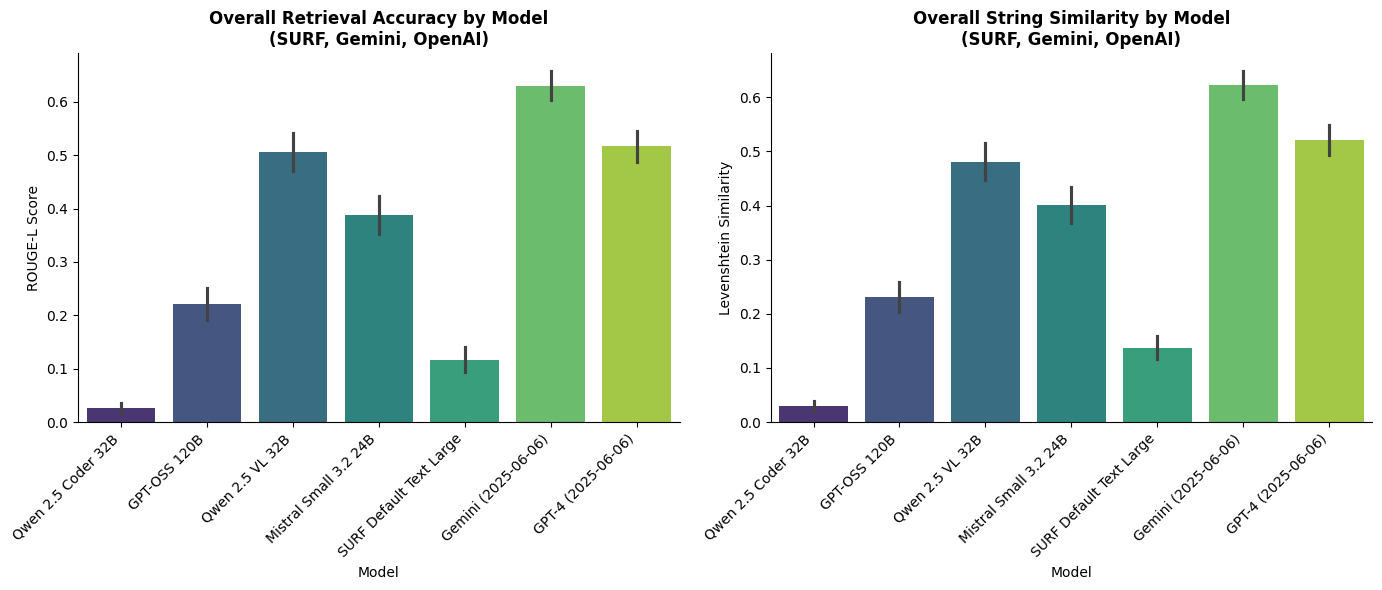

In [6]:
# Visualization 1: Overall ROUGE scores by model (including Gemini and OpenAI)
save_fig = True  # Enable saving figures

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# ROUGE scores by model (overall)
df_plot = df_scores[df_scores['annot_missing'] == False].copy()
sns.barplot(data=df_plot, 
            x='model_name', y='rouge', hue='model_name', errorbar='se', ax=ax[0],
            palette='viridis', legend=False)
ax[0].set_xlabel('Model')
ax[0].set_ylabel('ROUGE-L Score')
ax[0].set_title('Overall Retrieval Accuracy by Model\n(SURF, Gemini, OpenAI)', fontweight='bold')
ax[0].tick_params(axis='x', rotation=45)
plt.setp(ax[0].get_xticklabels(), ha='right')
despine(ax[0])

# Levenshtein scores by model (overall)
sns.barplot(data=df_plot, 
            x='model_name', y='levenshtein', hue='model_name', errorbar='se', ax=ax[1],
            palette='viridis', legend=False)
ax[1].set_xlabel('Model')
ax[1].set_ylabel('Levenshtein Similarity')
ax[1].set_title('Overall String Similarity by Model\n(SURF, Gemini, OpenAI)', fontweight='bold')
ax[1].tick_params(axis='x', rotation=45)
plt.setp(ax[1].get_xticklabels(), ha='right')
despine(ax[1])

plt.tight_layout()
if save_fig:
    os.makedirs(fig_dir, exist_ok=True)
    plt.savefig(os.path.join(fig_dir, 'benchmarking_model_comparison_overall.pdf'), bbox_inches='tight', dpi=300)
    plt.savefig(os.path.join(fig_dir, 'benchmarking_model_comparison_overall.png'), bbox_inches='tight', dpi=300)
plt.show()

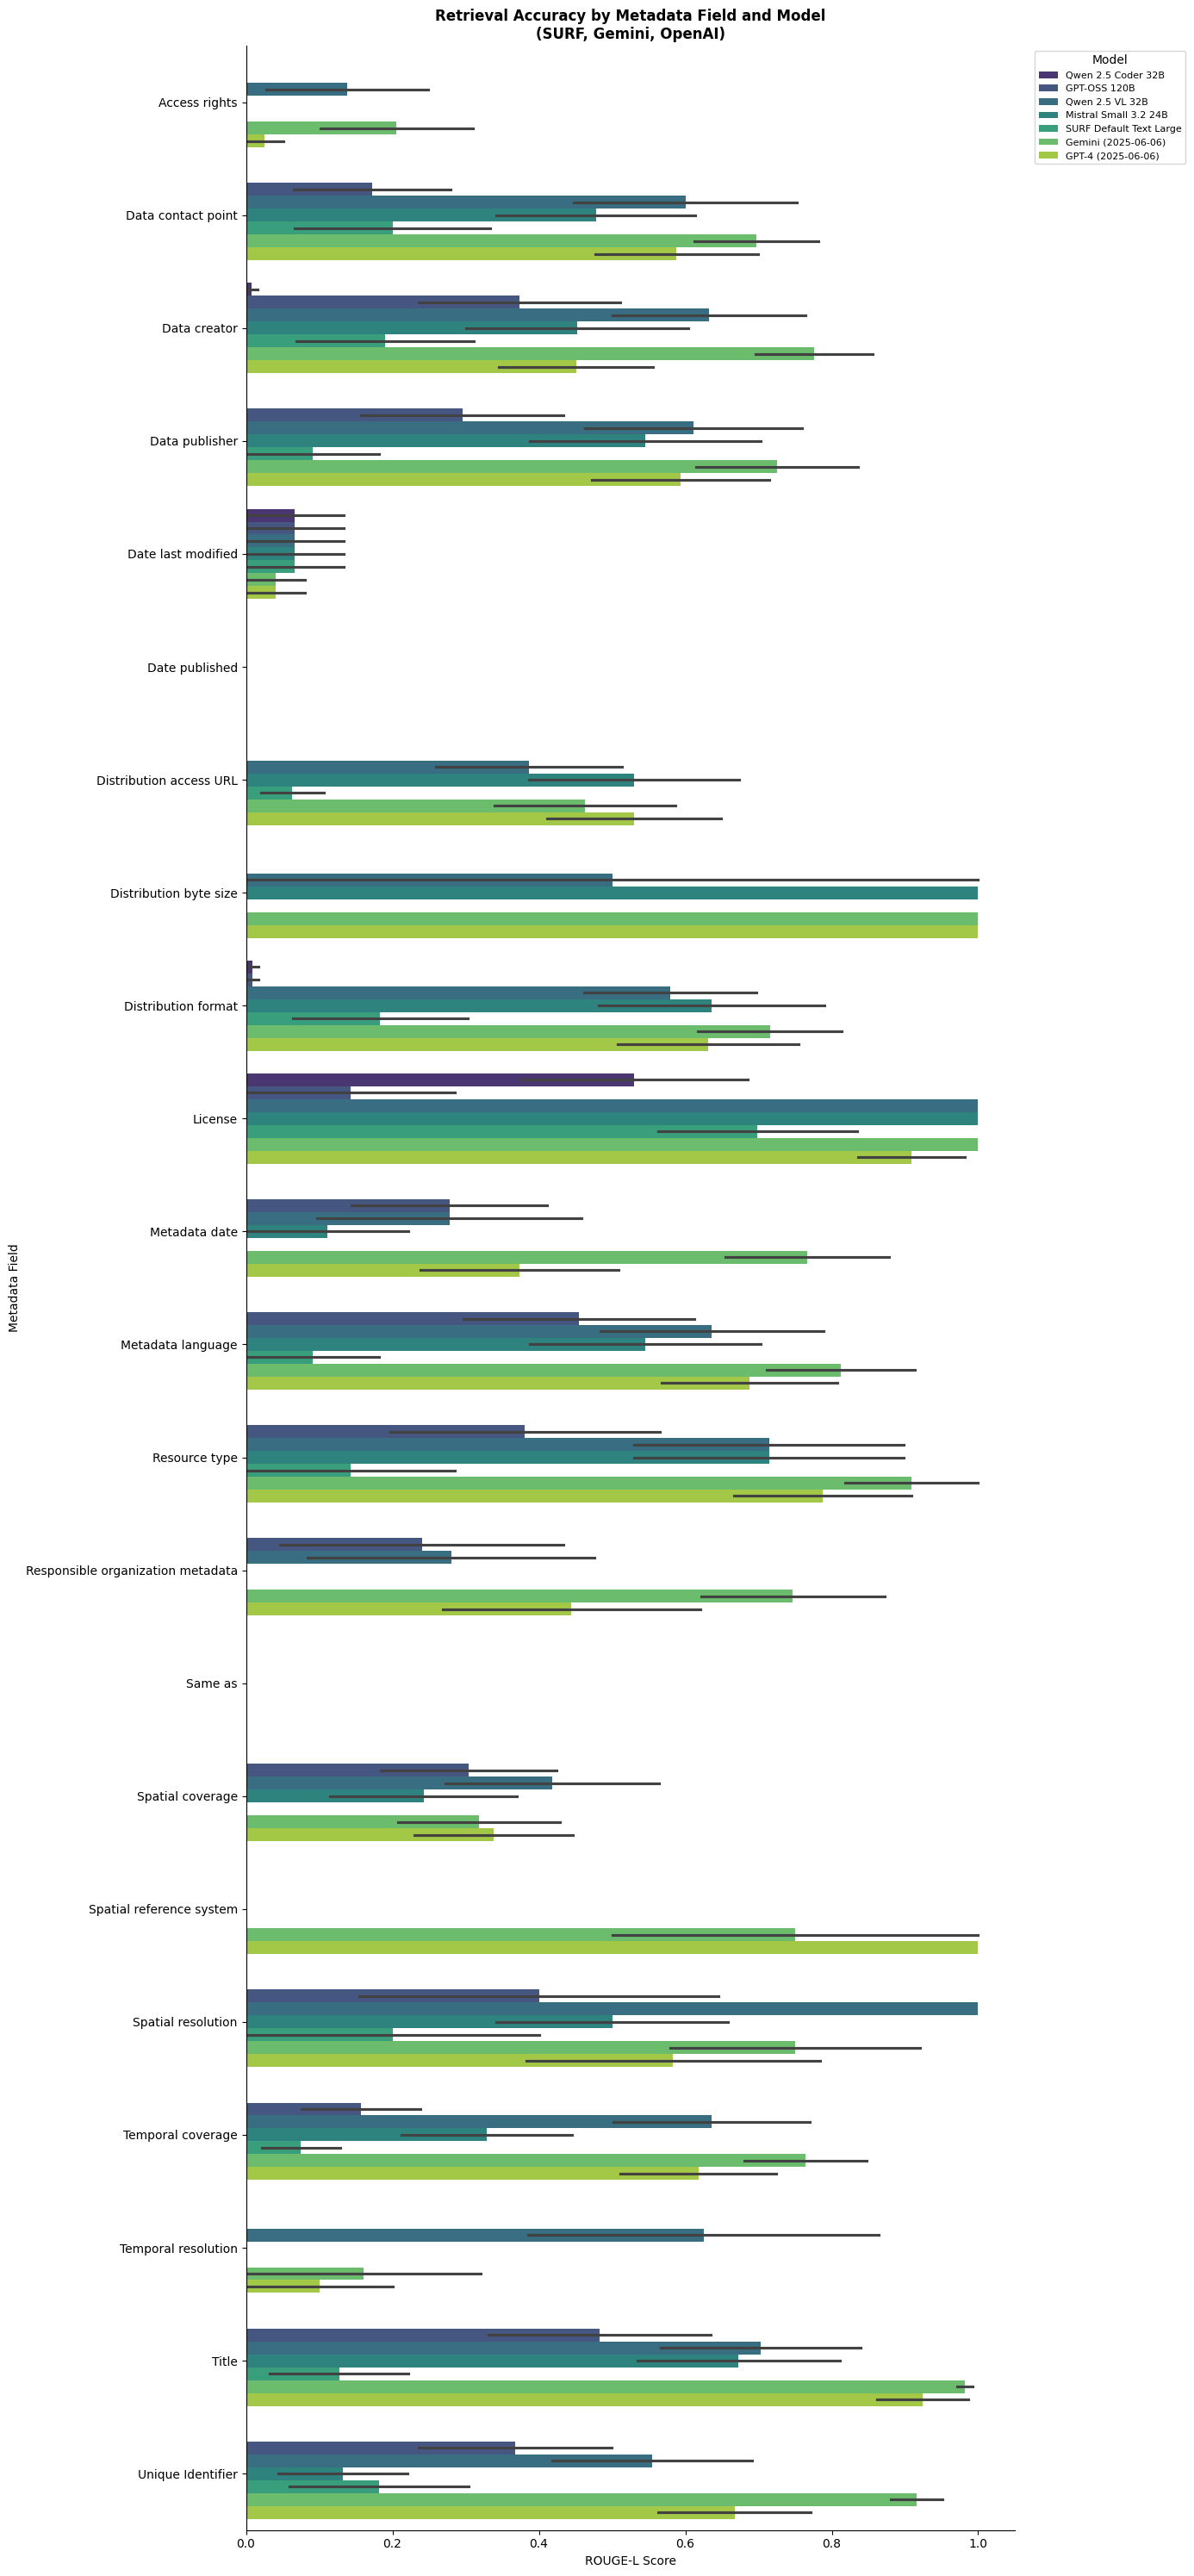

In [6]:
# Visualization 2: ROUGE scores by metadata field for each model
save_fig = True

# Only plot for non-missing annotations
df_plot = df_scores[df_scores['annot_missing'] == False].copy()

fig, ax = plt.subplots(1, 1, figsize=(14, 30))

sns.barplot(data=df_plot, 
            x='rouge', y='metadata_field', hue='model_name',
            orient='h', errorbar='se', ax=ax,
            palette='viridis')
ax.set_xlabel('ROUGE-L Score')
ax.set_ylabel('Metadata Field')
ax.set_title('Retrieval Accuracy by Metadata Field and Model\n(SURF, Gemini, OpenAI)', fontweight='bold')
ax.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
despine(ax)

plt.tight_layout()
if save_fig:
    plt.savefig(os.path.join(fig_dir, 'benchmarking_metadata_field_comparison.pdf'), bbox_inches='tight', dpi=300)
    plt.savefig(os.path.join(fig_dir, 'benchmarking_metadata_field_comparison.png'), bbox_inches='tight', dpi=300)
plt.show()

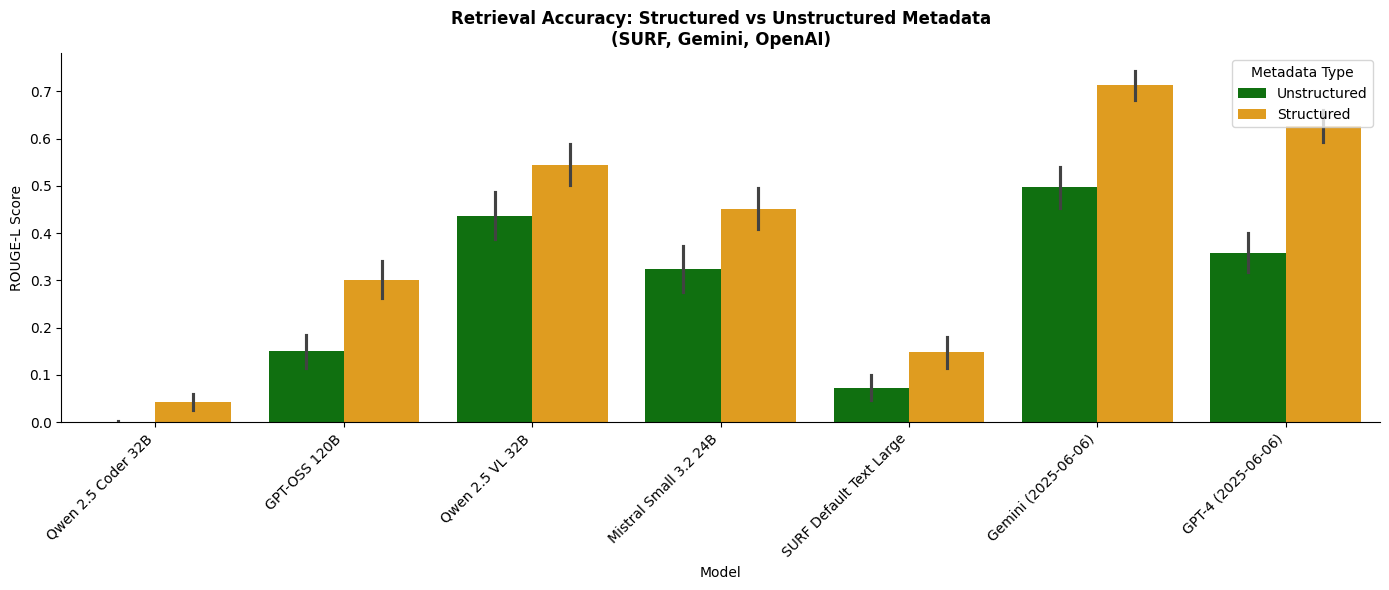

In [35]:
# Visualization 3: Structured vs Unstructured metadata comparison
save_fig = True

df_plot = df_scores[df_scores['annot_missing'] == False].copy()
df_plot['metadata_availability'] = df_plot['findability'].apply(
    lambda x: 'Structured' if x == 1 else ('Unstructured' if x == 2 else 'Unknown')
)
df_plot = df_plot[df_plot['metadata_availability'] != 'Unknown']

fig, ax = plt.subplots(1, 1, figsize=(14, 6))

sns.barplot(data=df_plot, 
            x='model_name', y='rouge', hue='metadata_availability',
            errorbar='se', ax=ax,
            palette=['#008000', '#ffa500'])
ax.set_xlabel('Model')
ax.set_ylabel('ROUGE-L Score')
ax.set_title('Retrieval Accuracy: Structured vs Unstructured Metadata\n(SURF, Gemini, OpenAI)', fontweight='bold')
ax.legend(title='Metadata Type', loc='upper right')
ax.tick_params(axis='x', rotation=45)
plt.setp(ax.get_xticklabels(), ha='right')
despine(ax)

plt.tight_layout()
if save_fig:
    plt.savefig(os.path.join(fig_dir, 'benchmarking_structured_vs_unstructured.pdf'), bbox_inches='tight', dpi=300)
    plt.savefig(os.path.join(fig_dir, 'benchmarking_structured_vs_unstructured.png'), bbox_inches='tight', dpi=300)
plt.show()

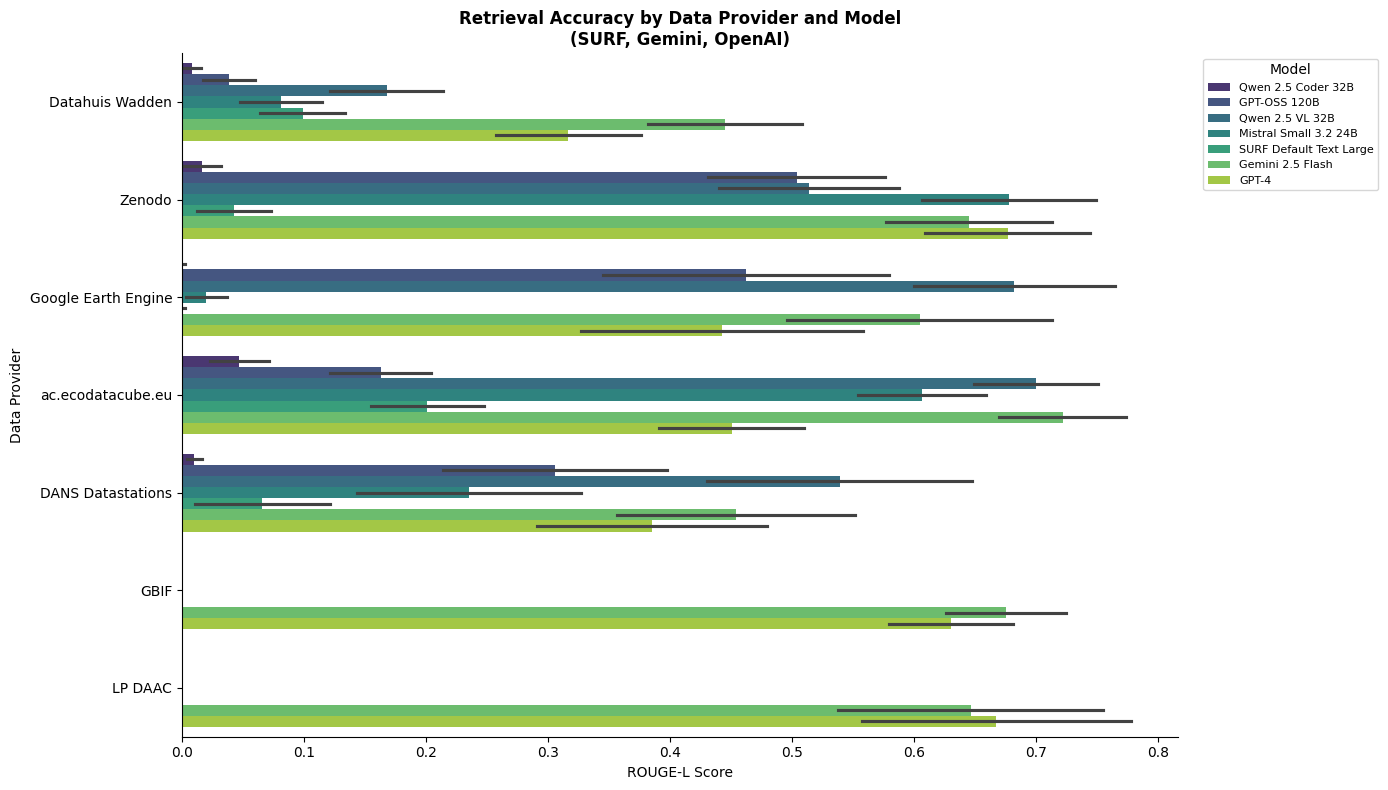

In [ ]:
# Visualization 4: Performance by data provider
save_fig = True

df_plot = df_scores[df_scores['annot_missing'] == False].copy()

fig, ax = plt.subplots(1, 1, figsize=(14, 8))

sns.barplot(data=df_plot, 
            x='rouge', y='provider', hue='model_name',
            orient='h', errorbar='se', ax=ax,
            palette='viridis')
ax.set_xlabel('ROUGE-L Score')
ax.set_ylabel('Data Provider')
ax.set_title('Retrieval Accuracy by Data Provider and Model\n(SURF, Gemini, OpenAI)', fontweight='bold')
ax.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
despine(ax)

plt.tight_layout()
if save_fig:
    plt.savefig(os.path.join(fig_dir, 'benchmarking_provider_comparison.pdf'), bbox_inches='tight', dpi=300)
    plt.savefig(os.path.join(fig_dir, 'benchmarking_provider_comparison.png'), bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
# Summary table: Mean scores by model
df_summary = df_scores[df_scores['annot_missing'] == False].groupby('model_name').agg({
    'rouge': ['mean', 'std', 'count'],
    'levenshtein': ['mean', 'std']
}).round(3)
df_summary.columns = ['ROUGE Mean', 'ROUGE Std', 'N Samples', 'Levenshtein Mean', 'Levenshtein Std']
df_summary = df_summary.sort_values('ROUGE Mean', ascending=False)

print("Model Performance Summary (excluding missing annotations)")
print("="*80)
print("Including: SURF models (2026-02-27), Gemini & GPT-4 (2025-06-06, 2025-07-01, 2025-07-22)")
print("="*80)
display(df_summary)

# Best performing model
best_model = df_summary['ROUGE Mean'].idxmax()
print(f"\nBest performing model: {best_model} (ROUGE-L: {df_summary.loc[best_model, 'ROUGE Mean']:.3f})")

# Save results
from datetime import datetime as dt
today_str = dt.now().strftime('%Y-%m-%d')
output_dir = f'outputs/{today_str}/'
os.makedirs(output_dir, exist_ok=True)

output_csv_path = os.path.join(output_dir, 'benchmarking_evaluation_results.csv')
df_scores.to_csv(output_csv_path, index=False)
print(f"\nEvaluation results saved to: {output_csv_path}")

summary_csv_path = os.path.join(output_dir, 'benchmarking_model_summary.csv')
df_summary.to_csv(summary_csv_path)
print(f"Model summary saved to: {summary_csv_path}")

print(f"\nFigures saved to: {fig_dir}")
print("  - benchmarking_model_comparison_overall.pdf/png")
print("  - benchmarking_metadata_field_comparison.pdf/png")
print("  - benchmarking_structured_vs_unstructured.pdf/png")
print("  - benchmarking_provider_comparison.pdf/png")

Model Performance Summary (excluding missing annotations)


,ROUGE Mean,ROUGE Std,N Samples,Levenshtein Mean,Levenshtein Std
model_name,,,,,
Qwen 2.5 VL 32B,0.495,0.453,190,0.473,0.441
Mistral Small 3.2 24B,0.393,0.451,190,0.407,0.431
GPT-OSS 120B,0.231,0.378,190,0.241,0.360
SURF Default Text Large,0.113,0.291,190,0.133,0.282
Qwen 2.5 Coder 32B,0.023,0.127,190,0.026,0.115



Best performing model: Qwen 2.5 VL 32B (ROUGE-L: 0.495)
